# End-to-End Workflow: Complex Function Learning

In this notebook, we cover the full lifecycle of a HeteroSymNN model: **Data Generation -> Model Creation -> Training -> Saving & Loading -> Inference.**

To make it interesting, we will tackle a complex task: learning a continuous 2D spatial pattern (mapping X, Y coordinates to RGB color channels) using a layer of mixed-frequency sine activations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from HeteroSymNN.Core.Nets import HeteroLinearNet
from HeteroSymNN.API import Wrapper

## 1. Generating the Dataset

We generate 5,000 random `(x, y)` points and compute three complex mathematical patterns based on radius and angle. These act as our target RGB channels.

In [2]:
def generate_data(num_data:int = 5000):
    X_gen = np.random.uniform(-1, 1, (num_data, 2))
    x = X_gen[:, 0]
    y = X_gen[:, 1]
    
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Three distinct, complex mathematical patterns
    out1 = np.sin(10 * r - 4 * theta)
    out2 = np.sin(5 * np.pi * x) * np.sin(5 * np.pi * y)
    out3 = np.exp(-5 * r**2) * np.cos(20 * r)
    
    # Normalize to [0, 1] for RGB visualization
    out1 = (out1 - out1.min()) / (out1.max() - out1.min())
    out2 = (out2 - out2.min()) / (out2.max() - out2.min())
    out3 = (out3 - out3.min()) / (out3.max() - out3.min())
    
    Y_gen = np.column_stack((out1, out2, out3))

    return X_gen, Y_gen

X_data, Y_data = generate_data()

## 2. Model Creation and Training

We use a `HeteroLinearNet` with a highly specialized first layer. Notice how we use the symbolic `sin(x*freq)` activation but group neurons into different frequency bands (1.0, 5.0, 10.0) alongside some standard `tanh` neurons.

This is a classic technique for spatial coordinate learning (similar to Fourier Features), and HeteroSymNN handles it natively in a single layer.

In [3]:
# Layer 1: 128 neurons total, split into 4 different functional groups
layer_1 = (
    [("sin(x*freq)", {"freq": 1.0})] * 32 + 
    [("sin(x*freq)", {"freq": 5.0})] * 32 + 
    [("sin(x*freq)", {"freq": 10.0})] * 32 + 
    [("tanh(x)", {})] * 32
)
                
layer_2 = [("tanh(x)", {})] * 32
output_layer = [("num",{})] * 3

layers = [layer_1, layer_2, output_layer]

nn = HeteroLinearNet(
    num_inputs=2,
    detailed_activations=layers,
    batch_size=128
)

model = Wrapper(nn, "class")

print("Training the model for 400 epochs...")
model.fit(X_data, Y_data, epochs=400)

Training the model for 400 epochs...


[np.float32(0.38780245),
 np.float32(0.13161361),
 np.float32(0.092837416),
 np.float32(0.08003199),
 np.float32(0.07467291),
 np.float32(0.06861807),
 np.float32(0.074988276),
 np.float32(0.07528064),
 np.float32(0.08367573),
 np.float32(0.061010405),
 np.float32(0.05605016),
 np.float32(0.0524008),
 np.float32(0.050450142),
 np.float32(0.048723754),
 np.float32(0.046558123),
 np.float32(0.045220003),
 np.float32(0.04366006),
 np.float32(0.04281483),
 np.float32(0.04074429),
 np.float32(0.039385308),
 np.float32(0.03653685),
 np.float32(0.035404738),
 np.float32(0.033449586),
 np.float32(0.03289658),
 np.float32(0.031886317),
 np.float32(0.032177888),
 np.float32(0.031974178),
 np.float32(0.033244006),
 np.float32(0.03226161),
 np.float32(0.032144792),
 np.float32(0.029052773),
 np.float32(0.027822575),
 np.float32(0.026013931),
 np.float32(0.025977954),
 np.float32(0.025269628),
 np.float32(0.026563032),
 np.float32(0.026458291),
 np.float32(0.027651746),
 np.float32(0.026205564),
 n

## 3. Saving and Loading the Model

Once trained, saving the model for deployment is just a single line of code. It bundles the architecture, symbolic formulas, and learned weights into a `.symnn` file.

We will immediately load it back into a new object to prove it works.

In [4]:
model_path = "spatial_pattern_model.symnn"

# 1. Save the trained model
model.save_model(model_path, overwrite=True)
print(f"Model saved to {model_path}")

# 2. Load the model from disk into a completely new wrapper
loaded_model = Wrapper.load_model(model_path)
print("Model successfully loaded from disk!")

Model saved to spatial_pattern_model.symnn
Model successfully loaded from disk!


## 4. Inference and Visualization

We generate a dense 150x150 grid of `(x, y)` coordinates and pass them through our **loaded model** to render the learned image. We will compare the model's output against the mathematical ground truth.

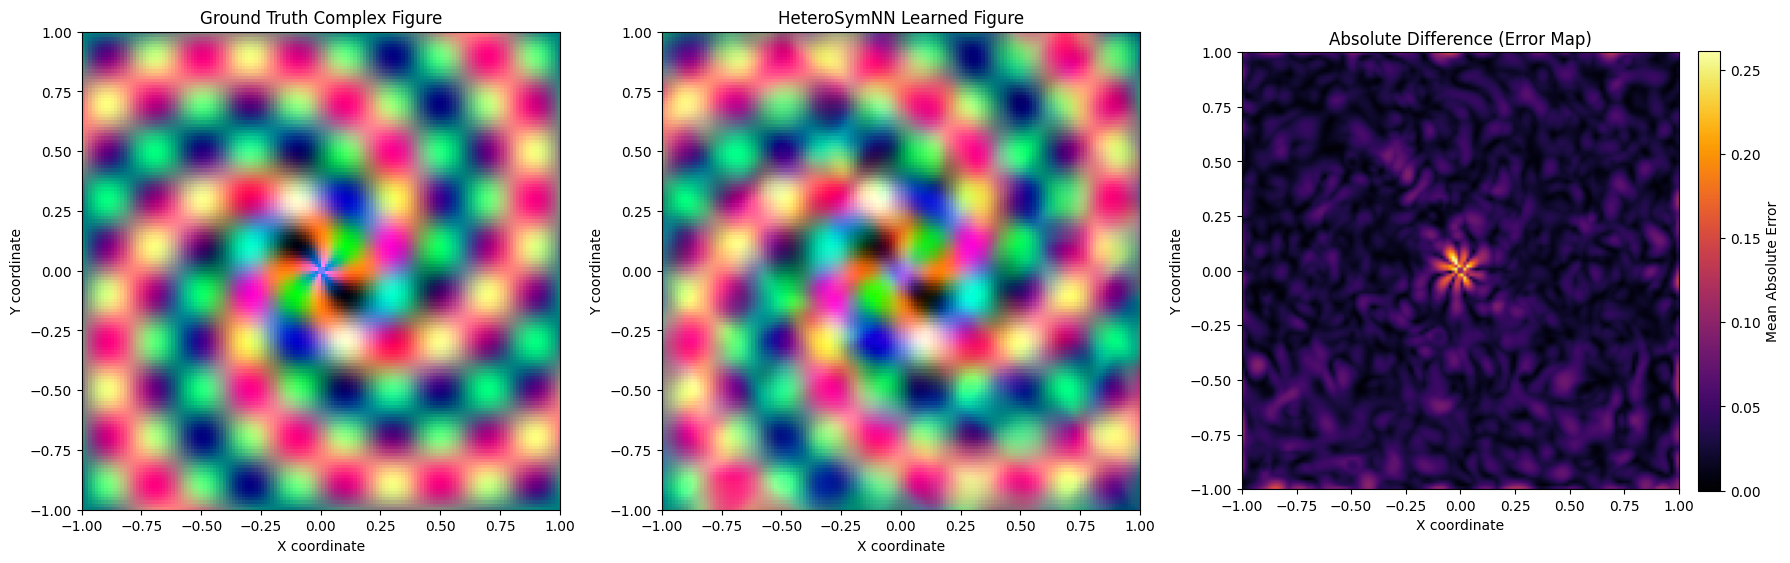

In [5]:
grid_res = 150
x_lin = np.linspace(-1, 1, grid_res)
y_lin = np.linspace(-1, 1, grid_res)
xx, yy = np.meshgrid(x_lin, y_lin)

X_test = np.column_stack((xx.ravel(), yy.ravel()))

# Using the loaded model for inference!
y_pred = loaded_model.predict(X_test)
image_pred = y_pred.reshape((grid_res, grid_res, 3))
image_pred_clipped = np.clip(image_pred, 0, 1)

# Generate true image for comparison
_, y_true_flat = generate_data(num_data=grid_res*grid_res)
r_grid = np.sqrt(xx**2 + yy**2)
theta_grid = np.arctan2(yy, xx)
out1_t = (np.sin(10 * r_grid - 4 * theta_grid) + 1) / 2
out2_t = (np.sin(5 * np.pi * xx) * np.sin(5 * np.pi * yy) + 1) / 2
out3_t = (np.exp(-5 * r_grid**2) * np.cos(20 * r_grid) + 1) / 2
image_true = np.stack([out1_t, out2_t, out3_t], axis=-1)

error_map = np.mean(np.abs(image_true - image_pred_clipped), axis=-1)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_true, origin='lower', extent=[-1, 1, -1, 1])
axes[0].set_title("Ground Truth Complex Figure")
axes[0].set_xlabel("X coordinate")
axes[0].set_ylabel("Y coordinate")

axes[1].imshow(image_pred_clipped, origin='lower', extent=[-1, 1, -1, 1])
axes[1].set_title("HeteroSymNN Learned Figure")
axes[1].set_xlabel("X coordinate")
axes[1].set_ylabel("Y coordinate")

im = axes[2].imshow(error_map, origin='lower', extent=[-1, 1, -1, 1], cmap='inferno', vmin=0)
axes[2].set_title("Absolute Difference (Error Map)")
axes[2].set_xlabel("X coordinate")
axes[2].set_ylabel("Y coordinate")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Mean Absolute Error")

plt.tight_layout()
plt.show()